In [1]:
using Pkg
using CSV
using DataFrames
using Polynomials
using CairoMakie
using Statistics

In [74]:
include("D:/01 Projekt/03 Programm/Rini aktuell/Rini/src/TIRA.jl")

Main.TIRA

## Plots


### fig1

In [82]:
# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

Axis with 0 plots:


In [83]:
# Plot the first curve with lines and markers
fig50 = Figure(resolution = (1000, 600))
font=24
ax1_50= Axis(fig50[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_50 = Axis(fig50[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

Axis with 0 plots:


## Proben Geometrie

In [84]:
## Geometrie
w=10*1e-3 # Width
t=15*1e-6 # thickness
l=60*1e-3 # length between clamps
As=w*t    # stress section

1.5e-7

## Raum Temperature

In [85]:

BaseName="AP5ZMEF01/20260121-"
name="260121-"
file_path = "$(BaseName)$(2).csv"

"AP5ZMEF01/20260121-2.csv"

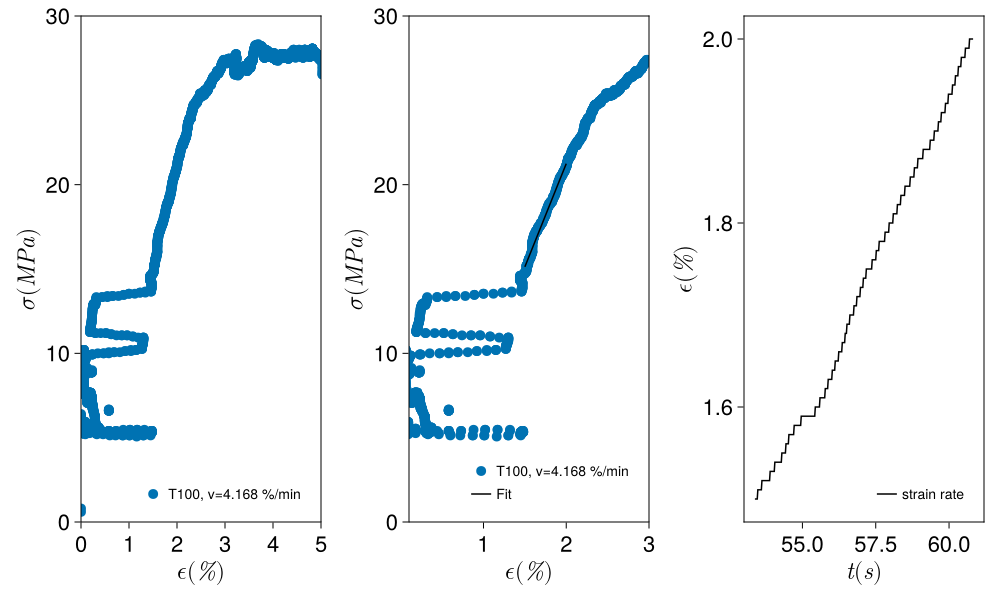

In [102]:

#### Raum T

BaseName="AP5ZMEF01/20260121-"
name="260121-"

DataProperties=[]


# Plot the first curve with lines and markers
figRaum = Figure(resolution = (1000, 600))
font=24
ax1_Raum = Axis(figRaum[1,1],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax2_Raum = Axis(figRaum[1,2],
    xlabel = L"\epsilon (%)",
    ylabel = L"\sigma (MPa)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

ax3_Raum = Axis(figRaum[1,3],
    xlabel = L"t (s)",
    ylabel = L"ϵ (%)",
    xlabelsize = font,
    ylabelsize = font,
    xticklabelsize = font - 2,
    yticklabelsize = font - 2,
    xgridstyle = :dash,        # dashed grid
    ygridstyle = :dash,
    xgridvisible = false,
    ygridvisible = false
)

for i in [5]
        
        df=TIRA.computeStressStrain(BaseName,name,i,100,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties, df_fit=TIRA.computeProperties(df,[1.5 2],[0 50])
        
        df_Properties=DataFrame(properties)

        Makie.scatter!(ax1_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        limits!(ax1_Raum, 0, 5, 0, 30)


        Makie.scatter!(ax2_Raum ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T100, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_Raum ,df_fit[!,:Strain],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_Raum, 0.1, 3,0,30)

        Makie.lines!(ax3_Raum ,df_fit[!,:Zeit],df_fit[!,:Strain];
        color = :black, 
        label = "strain rate")
        #limits!(ax3_Raum, 0.1, 1,0,30)



        push!(DataProperties,properties)
        
end

df_DataProperties=DataFrame(DataProperties)

axislegend(ax1_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax2_Raum, labelsize=font-10, framevisible=false,position = :rb)
axislegend(ax3_Raum, labelsize=font-10, framevisible=false,position = :rb)
figRaum

In [103]:
df_DataProperties

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,3.41375,54.2005,260121-5,3.69,"[1.5, 2.0]",0.642093,100,1.22297,28.3333,21.1333,4.16763


## Temperature 50

In [37]:
####  T 50

#### Gesamtgruppe um 50 °C

BaseName="AP5ZK04/251103-"
name="251103-"

DataProperties=[]
df_Data=[]

   for i in [3,4,5,6,7]

        df=TIRA.computeStressStrain(BaseName,name,i,50,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[0.1 0.5],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)

        Makie.scatter!(ax1_50 ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")
        
        
        limits!(ax1_50, 0, 5, 0, 75)


        Makie.scatter!(ax2_50 ,df[!,:Strain],df[!,:Stress];
        markersize=14, 
        label = "T22, v=$(round(df_Properties[1," Strain Rate[%/min]"], digits=3)) %/min")

        Makie.lines!(ax2_50 ,df_fit[!,:StrainFit],df_fit[!,:StressFit];
        color = :black, 
        label = "Fit")
        limits!(ax2_50, 0.1, 1,0,50)

        push!(DataProperties,properties)


    end

    df_DataProperties=DataFrame(DataProperties)



UndefVarError: UndefVarError: `df_Properties` not defined

In [37]:
####  T 100

#### Gesamtgruppe um 100 °C

BaseName="AP5ZK04/251103-"
name="251103-"

DataProperties=[]
df_Data=[]

   for i in [8,9,10]

        df=TIRA.computeStressStrain(BaseName,name,i,100,As)
        df=TIRA.filter_range(df,"dL_ORG",0,10)
        properties=TIRA.computeProperties(df,[1.2 2],[0 100])
        push!(DataProperties,properties)
        push!(df_Data,df)

    end

    df_DataProperties=DataFrame(DataProperties)

Row,e_max[%],δ_F/δ_B,Probe,δ_B,LinearRange [%],u_E[%],Temperature [C],E[GPa],sigmaMax,sigma0_25%,Strain Rate[%/min]
,Float64,Float64,String,Float64,Array…,Float64,Int64,Float64,Float64,Float64,Float64
1,7.86049,54.4959,251103-8,3.67,"[1.2, 2.0]",2.48205,100,1.65069,29.2667,25.6667,20.2033
2,13.7458,93.0233,251103-9,2.15,"[1.2, 2.0]",16.5943,100,0.160578,24.8,24.2667,1.18137
3,3.12264,71.8412,251103-10,2.77,"[1.2, 1.99]",0.869729,100,1.32388,25.5333,19.8,25.0633
